In [1]:
file_read = "004_fit_MPAA"
file_write = "006_coefs_MPAA"

In [2]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
n_features_min = 13

In [4]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features_min)

In [5]:
df_coefs_

backbone_test,n_features,alpha,12,21,46,91,148,157,161,232,234,235,237,240,247,252,255,270,271,275,293,324,327,355,357,415,442,465,469,494,505,506,507,519,538,540,543,575,597,602,605,642
i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,13,53.33,null,0.154433,-0.086928,0.158574,null,null,null,null,-0.085888,0.119356,null,null,null,null,null,null,null,null,null,null,null,0.112466,null,null,null,-0.139976,0.109452,0.101284,null,-0.172683,null,null,0.127788,-0.138098,null,0.084661,null,null,null,null
1,13,41.67,0.106157,0.165209,-0.102587,0.101291,null,null,null,null,-0.101911,0.143833,null,null,null,null,null,null,null,null,null,null,null,0.116934,null,null,null,-0.15929,0.114436,0.126646,null,-0.210156,null,null,0.133027,-0.132601,null,null,null,null,null,null
2,13,50.17,0.102394,0.153672,-0.080346,0.157123,null,null,null,null,-0.095749,0.125273,null,null,null,null,null,null,null,null,null,null,null,0.12086,null,null,null,-0.151479,0.12073,0.087097,null,-0.203547,null,null,0.119965,-0.12099,null,null,null,null,null,null
3,13,73.32,null,0.114186,null,0.10565,null,null,null,null,null,0.111082,null,null,null,null,-0.071483,0.077541,null,null,-0.071175,null,null,0.086242,null,null,null,-0.12174,0.101304,null,null,-0.128904,null,null,0.153109,-0.109516,null,0.067796,null,null,null,null
4,13,95.0,null,0.109681,null,0.081291,null,null,null,null,null,0.086926,null,null,null,null,null,null,null,null,-0.0838,null,null,0.100004,null,null,-0.065814,-0.109332,0.106778,0.072633,null,-0.120693,null,null,0.1054,-0.066168,null,null,null,null,null,0.086111
5,13,2.41,0.322885,0.141707,null,-0.161161,null,-0.420247,null,null,-0.224386,null,null,null,0.132132,null,null,0.215449,null,null,null,null,null,0.197622,null,-0.360439,-0.178711,null,null,0.263637,null,null,-0.341298,null,null,null,-0.162219,null,null,null,null,null
19,13,92.08,0.063444,0.108493,null,0.128491,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.052786,null,null,0.080335,null,null,null,-0.102131,0.125349,0.087187,null,-0.124943,null,null,0.088732,-0.095649,null,null,0.075025,null,null,0.075595
20,13,1.94,0.185144,0.310617,null,0.388395,null,null,null,null,-0.256532,0.236762,null,null,null,null,null,null,null,null,null,-0.204851,null,0.303017,null,-0.245889,0.435573,-0.552853,null,null,null,null,null,null,null,-0.597417,null,0.195218,null,null,0.233683,null


In [6]:
columns_feat = [c for c in df_coefs_.columns if c.isnumeric()]

In [7]:
data = df_coefs_[columns_feat].to_numpy()

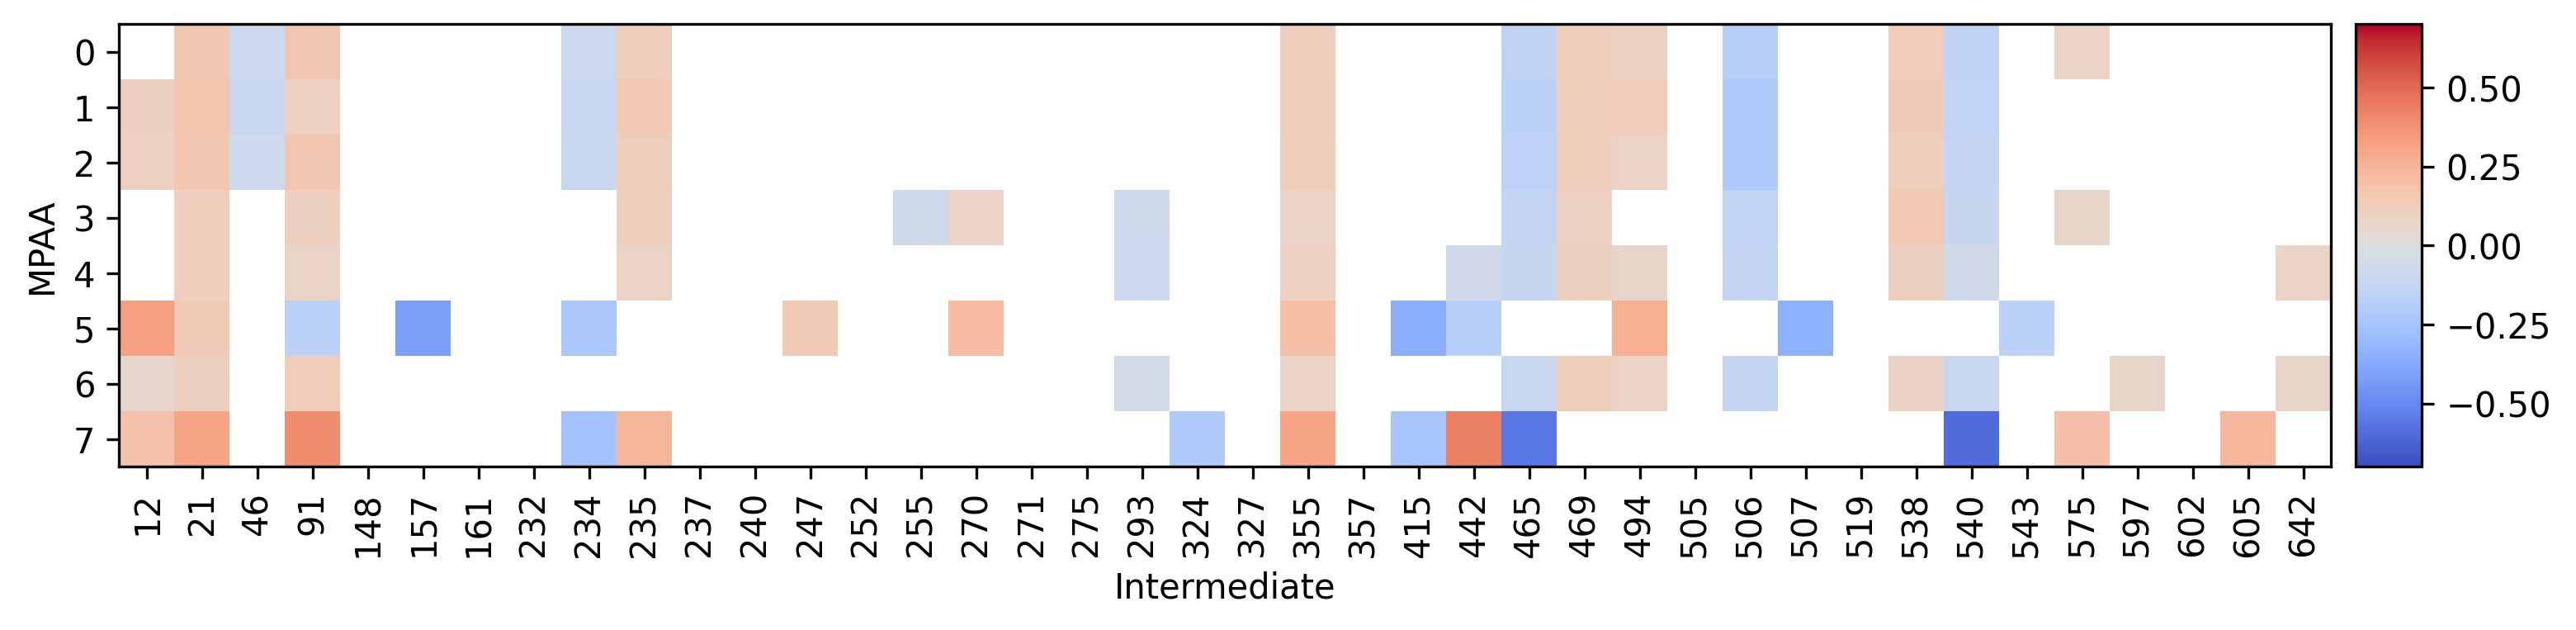

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-0.7, vmax=0.7, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("MPAA")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels(columns_feat, rotation=90)
ax.set_yticklabels(np.arange(data.shape[0]))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
data_std = np.where(data_std == 0.0, np.nan, data_std)

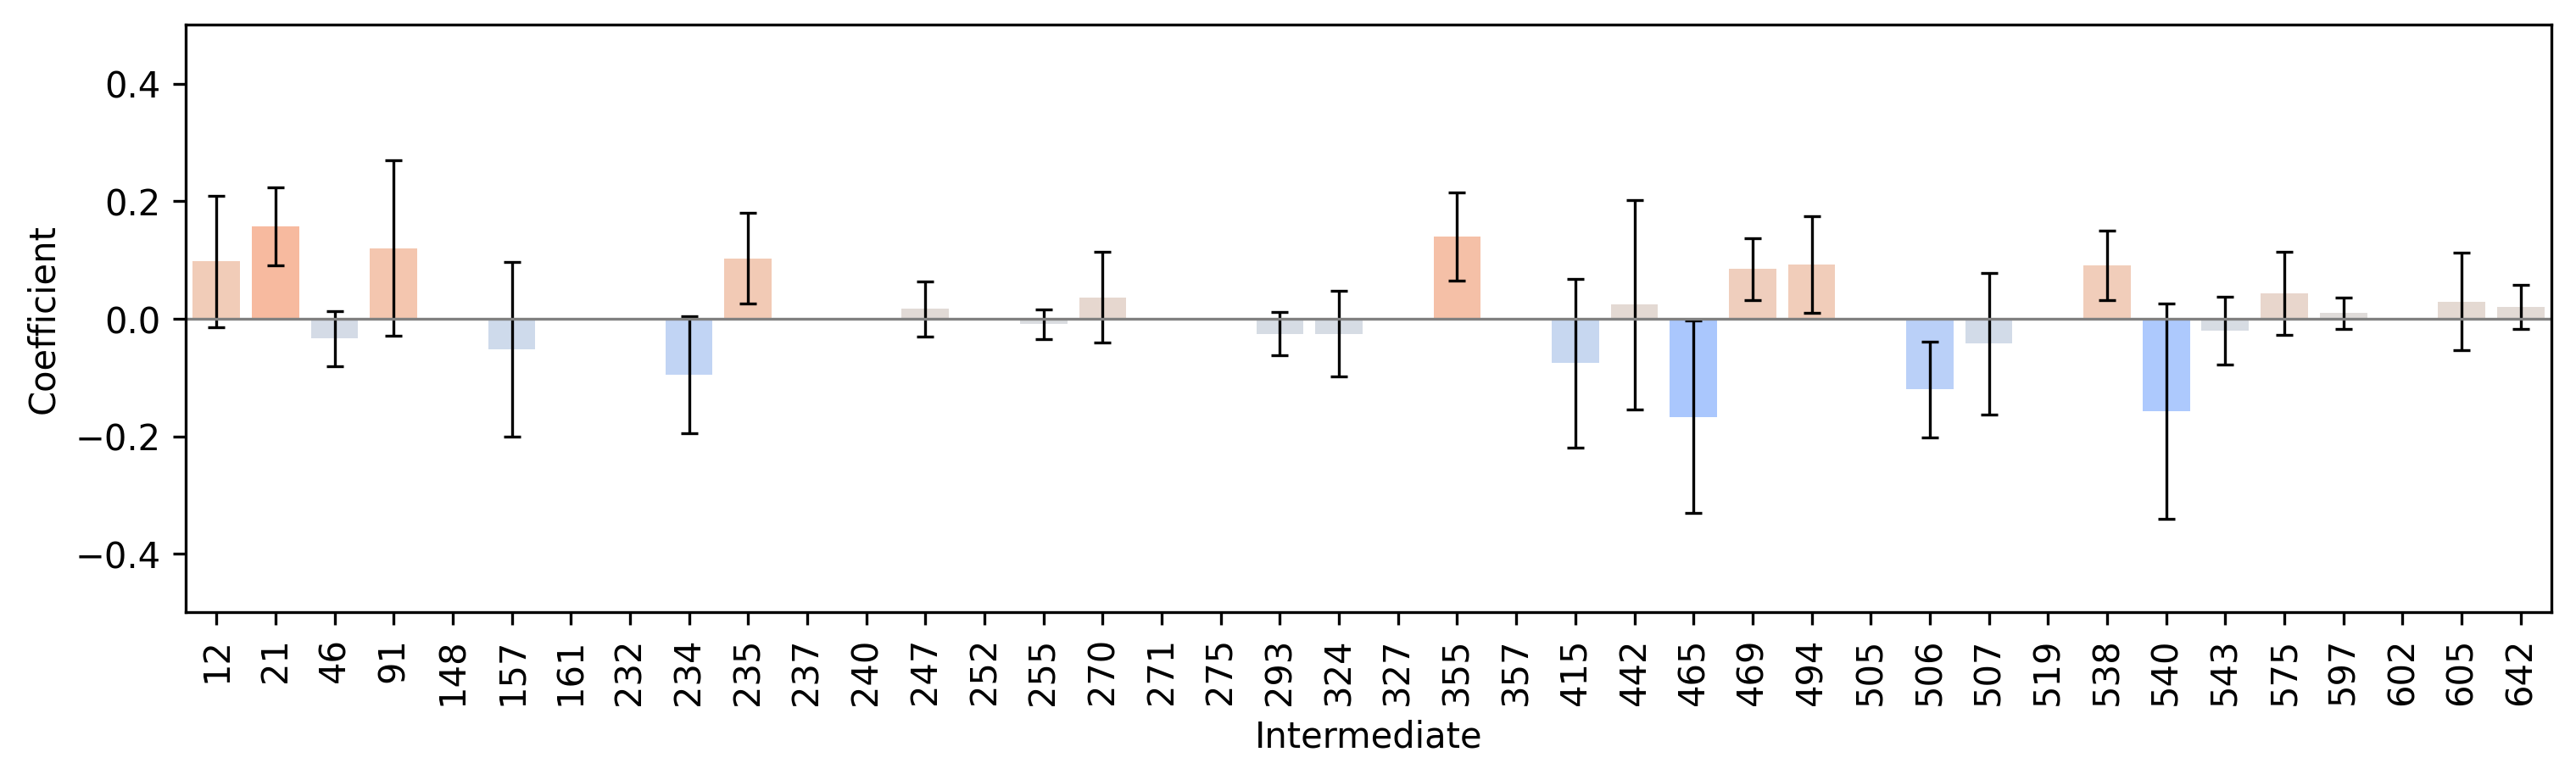

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
colors = plt.cm.coolwarm(norm(data_mean))
error_kw = dict(elinewidth=0.8, capthick=0.8)
ax.bar(
    np.arange(len(data_mean)),
    data_mean,
    yerr=data_std,
    color=colors,
    capsize=2.5,
    error_kw=error_kw
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_mean)))
ax.set_xticklabels(columns_feat, rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-0.5, 0.5)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()